#**1. Loading Data**


In [ ]:
import pandas as pd

data = pd.read_excel('/content/drive/MyDrive/Project/Regression - Zone4.xlsx',index_col=None)

data.head()

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam,V4,A4
0,191,241,238,236,249,8.2,8514,1321,45,0,3
1,194,240,235,234,251,8.2,7184,1158,45,0,4
2,194,241,233,234,249,8.2,8546,1350,50,0,6
3,194,242,242,234,250,8.7,8337,1427,50,0,5
4,195,239,239,237,250,8.3,8262,1409,45,0,2


In [ ]:
len(data)

269

# **2. Preparing Data**

In [ ]:
# Split into X and y

X = data.drop('A4', axis=1)
y = data['A4']

In [ ]:
X

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam,V4
0,191,241,238,236,249,8.2,8514,1321,45,0
1,194,240,235,234,251,8.2,7184,1158,45,0
2,194,241,233,234,249,8.2,8546,1350,50,0
3,194,242,242,234,250,8.7,8337,1427,50,0
4,195,239,239,237,250,8.3,8262,1409,45,0
...,...,...,...,...,...,...,...,...,...,...
264,195,233,236,237,251,7.9,8276,1388,50,0
265,183,233,230,232,252,7.9,7986,1331,45,0
266,183,233,237,233,251,7.9,7969,1384,45,0
267,188,231,241,237,250,9.3,8065,1288,40,0


In [ ]:
y

0      3
1      4
2      6
3      5
4      2
      ..
264    2
265    6
266    5
267    1
268    2
Name: A4, Length: 269, dtype: int64

In [ ]:
# Split data into training and test data

from sklearn.model_selection import train_test_split
import numpy as np

np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
X_train

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam,V4
115,194,239,239,238,252,7.50,8300,1435,40,0
33,192,242,238,241,250,8.10,8544,1471,40,1
180,191,239,241,238,250,7.70,8085,1270,45,0
141,190,236,235,235,251,7.40,8495,1445,40,0
248,187,235,238,238,249,7.90,8257,1350,45,0
...,...,...,...,...,...,...,...,...,...,...
20,196,241,238,235,249,8.40,8591,1299,50,0
188,191,239,234,237,249,7.75,8067,1325,35,0
71,194,238,236,236,249,7.90,8232,1312,35,0
106,186,237,238,239,250,7.50,8290,1335,40,0


In [ ]:
X_test

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam,V4
30,194,238,240,237,250,8.10,8374,1459,50,0
116,194,238,236,234,251,7.50,8460,1470,35,0
79,186,242,239,234,250,8.50,8481,1310,40,0
127,189,239,238,233,249,7.50,8377,1419,45,0
190,191,240,237,235,248,7.50,8322,1403,45,0
137,191,240,242,241,251,7.50,8258,1318,50,1
202,191,241,233,235,251,7.75,8271,1430,45,0
45,191,241,238,235,249,8.20,8314,1470,45,0
173,192,232,237,236,251,7.70,8251,1290,50,0
239,191,239,235,235,251,8.50,8135,1440,45,0


In [ ]:
y_train

115    1
33     0
180    0
141    5
248    0
      ..
20     5
188    1
71     3
106    0
102    2
Name: A4, Length: 215, dtype: int64

In [ ]:
y_test

30     2
116    5
79     6
127    6
190    4
137    0
202    4
45     4
173    3
239    3
179    4
267    1
220    4
82     2
186    3
185    3
241    5
265    6
104    3
60     3
261    3
184    2
46     5
42     0
181    2
9      3
22     0
193    2
109    4
24     0
113    5
68     0
143    4
217    4
197    3
6      3
120    4
67     0
119    5
118    4
25     1
125    1
165    0
19     3
77     4
209    5
90     4
170    4
93     5
258    4
15     5
150    2
224    2
242    5
Name: A4, dtype: int64

In [ ]:
y_test.value_counts()

4    14
3    11
5     9
2     7
0     7
6     3
1     3
Name: A4, dtype: int64

In [ ]:
y_train.value_counts()

4    41
5    40
0    38
3    33
2    26
1    19
6    13
7     4
8     1
Name: A4, dtype: int64

##Pearson Correlation  (detecting correlated data)

<function matplotlib.pyplot.show(*args, **kw)>

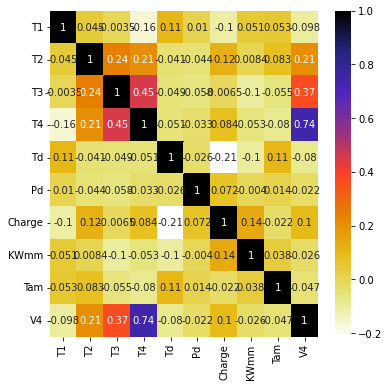

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Using Pearson Correlation
plt.figure(figsize=(6,6))
cor = X.corr(method='pearson')
#cor2 = X.corr(method='spearman')
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
#sns.heatmap(cor2, annot=True, cmap=plt.cm.CMRmap_r)
plt.show

# **3. Building Machine Learning Model**

## All Models

In [ ]:
!pip install catboost
!pip install logitboost

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 76.6 MB 1.2 MB/s 
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


# 3.1. Ridge Model

In [ ]:
from sklearn.linear_model import Ridge
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
model = Ridge()
model.fit(X_train, y_train)

Ridge()

In [ ]:
#Evaluate our model
model.score(X_test, y_test)

0.9392276714085482

In [ ]:
# Cross-validation
from sklearn.model_selection import cross_val_score
cross_val_score(model, X, y, cv=5)

array([  0.92250667,   0.91769095,   0.8963029 , -31.57057324,
         0.91083904])

In [ ]:
#Use the trained model to make predictions

y_preds = model.predict(X_test)
#y_preds[:10]
y_preds

array([ 2.46361065e+00,  5.21714726e+00,  5.32017462e+00,  5.94735681e+00,
        4.10927489e+00,  7.22141389e-02,  3.89026043e+00,  4.04642722e+00,
        3.06516985e+00,  3.57886547e+00,  3.74113505e+00,  1.75351256e+00,
        3.62981216e+00,  1.04637875e+00,  3.59161620e+00,  3.06227721e+00,
        4.83950112e+00,  5.77760403e+00,  2.93370671e+00,  3.44849751e+00,
        3.30660225e+00,  2.06311447e+00,  4.72627384e+00,  1.32128190e-01,
        2.24324263e+00,  3.26409600e+00, -1.31891961e-04,  2.27908747e+00,
        3.93243808e+00, -7.37432027e-01,  5.09601386e+00, -5.15208053e-01,
        3.92281848e+00,  4.10831749e+00,  2.91570523e+00,  2.72818796e+00,
        4.76894100e+00,  7.28100170e-01,  4.84041313e+00,  4.19054761e+00,
        8.20023118e-01,  2.14714629e+00, -3.61570756e-01,  3.06720248e+00,
        4.31654225e+00,  4.39596902e+00,  4.50613930e+00,  4.54248757e+00,
        4.41430480e+00,  3.47163239e+00,  4.78923116e+00,  2.62545947e+00,
        2.26955794e+00,  

In [ ]:
#y_test[:10]
y_test

30     2
116    5
79     6
127    6
190    4
137    0
202    4
45     4
173    3
239    3
179    4
267    1
220    4
82     2
186    3
185    3
241    5
265    6
104    3
60     3
261    3
184    2
46     5
42     0
181    2
9      3
22     0
193    2
109    4
24     0
113    5
68     0
143    4
217    4
197    3
6      3
120    4
67     0
119    5
118    4
25     1
125    1
165    0
19     3
77     4
209    5
90     4
170    4
93     5
258    4
15     5
150    2
224    2
242    5
Name: A4, dtype: int64

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, median_absolute_error, max_error
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 0.17791953675762143
mean_absolute_error= 0.330455005880247
mean_absolute_percentage_error= 212401870316454.03
median_absolute_error= 0.2614804770608714
max_error= 1.1471462901638745


# 3.2. Random Forest Regression Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
rf = RandomForestRegressor(max_depth= 20,
 max_features= 'auto',
 min_samples_leaf= 1,
 min_samples_split= 8,
 n_estimators= 100)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_split=8)

In [ ]:
#Evaluate our model
rf.score(X_test, y_test)

0.9649790579176706

In [ ]:
# Cross-validation
from sklearn.model_selection import cross_val_score
cross_val_score(rf, X, y, cv=5)

array([0.96734817, 0.96016051, 0.9227512 , 0.95013352, 0.88783547])

In [ ]:
y_preds = rf.predict(X_test)
y_preds

array([1.9955    , 5.38840677, 5.55783185, 6.24673983, 3.93622222,
       0.        , 3.9885    , 4.03166667, 3.0052904 , 3.30453319,
       3.31046176, 1.12929157, 3.57256609, 2.16695112, 3.31229509,
       2.66195707, 5.01333333, 5.88804892, 2.92259524, 3.39931284,
       2.73420833, 1.79398277, 4.93791667, 0.00857143, 2.0655    ,
       3.017     , 0.22918434, 2.        , 3.9505    , 0.        ,
       5.08375201, 0.0195    , 3.9371746 , 3.95916667, 2.82133802,
       2.81571825, 4.53786905, 0.57553152, 4.98333333, 4.03763492,
       0.91485039, 2.055     , 0.12190368, 2.98779365, 4.31894084,
       4.77118254, 3.93138889, 4.89241667, 4.51624695, 3.54870894,
       4.98328571, 2.7285754 , 2.03940476, 4.99041667])

In [ ]:
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 0.10252873201537947
mean_absolute_error= 0.20958722046834796
mean_absolute_percentage_error= 79621220784738.06
median_absolute_error= 0.09855034752828834
max_error= 1.0550000000000002


## 3.3. KNeighbours Regression Model

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
neigh = KNeighborsRegressor(n_neighbors = 50)
neigh.fit(X_train,y_train)

KNeighborsRegressor(n_neighbors=50)

In [ ]:
#Evaluate our model
neigh.score(X_test, y_test)

0.0038723673421577898

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(neigh, X, y, cv=5)

array([-0.01806006, -0.08158625,  0.02770706,  0.04080301, -0.32657877])

In [ ]:
y_preds = neigh.predict(X_test)
y_preds

array([3.16, 3.5 , 3.44, 3.2 , 3.1 , 2.64, 3.24, 3.24, 2.6 , 2.9 , 2.56,
       2.74, 3.82, 2.58, 2.56, 2.66, 2.72, 2.58, 3.32, 2.9 , 2.5 , 2.48,
       3.14, 2.6 , 3.04, 2.36, 3.52, 3.02, 3.24, 3.38, 3.54, 3.06, 2.84,
       2.76, 3.14, 3.46, 3.12, 2.62, 2.98, 3.22, 3.1 , 2.88, 3.42, 3.14,
       3.58, 3.64, 2.68, 2.54, 2.66, 3.38, 2.84, 3.54, 2.86, 3.04])

In [ ]:
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 2.916303703703704
mean_absolute_error= 1.4003703703703705
mean_absolute_percentage_error= 1771415853432395.2
median_absolute_error= 1.2000000000000002
max_error= 3.52


# 3.4. DecisionTree Regression Model

In [ ]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
dt = DecisionTreeRegressor(random_state=1)
dt.fit(X_train,y_train)

DecisionTreeRegressor(random_state=1)

In [ ]:
#Evaluate our model
dt.score(X_test, y_test)

0.9114443012767951

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(dt, X, y, cv=5)

array([0.9047283 , 0.93758188, 0.89768648, 0.91468158, 0.84912321])

In [ ]:
y_preds = dt.predict(X_test)
y_preds

array([2., 6., 6., 6., 4., 0., 4., 4., 3., 4., 3., 1., 3., 2., 4., 2., 5.,
       5., 3., 4., 2., 2., 5., 0., 2., 3., 0., 2., 4., 0., 5., 0., 4., 4.,
       3., 3., 5., 1., 5., 4., 1., 2., 0., 3., 4., 5., 4., 5., 4., 4., 5.,
       2., 2., 5.])

In [ ]:
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 0.25925925925925924
mean_absolute_error= 0.25925925925925924
mean_absolute_percentage_error= 83399993099453.7
median_absolute_error= 0.0
max_error= 1.0


# 3.5. XGBOOST Regressor

In [ ]:
from xgboost import XGBRegressor
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
xgb = XGBRegressor( max_depth=50, learning_rate=0.1, n_estimators=100)
xgb.fit(X_train,y_train)

[06:12:06] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


XGBRegressor(max_depth=50)

In [ ]:
#Evaluate our model
xgb.score(X_test, y_test)

0.9405674289016598

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(xgb, X, y, cv=5)

[06:12:06] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[06:12:06] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[06:12:06] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[06:12:07] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[06:12:07] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


array([0.96082261, 0.94416315, 0.90529152, 0.9431171 , 0.87044   ])

In [ ]:
y_preds = xgb.predict(X_test)
y_preds

array([ 1.9889812e+00,  5.8782725e+00,  5.1062884e+00,  6.2582779e+00,
        3.9493675e+00,  6.4224005e-05,  4.0602312e+00,  4.0065184e+00,
        2.9252017e+00,  3.9460406e+00,  3.7353160e+00,  1.0065281e+00,
        3.9631047e+00,  1.9680452e+00,  3.7839668e+00,  2.1713176e+00,
        5.0027161e+00,  6.0240083e+00,  2.8709490e+00,  3.6468203e+00,
        2.1372595e+00,  1.9651709e+00,  4.9958568e+00,  6.4224005e-05,
        1.9980235e+00,  2.9994519e+00,  3.1454623e-01,  2.0026839e+00,
        3.9983339e+00, -3.6954880e-06,  5.1205192e+00,  1.0441840e-03,
        4.0064411e+00,  3.8911662e+00,  2.9174249e+00,  2.9683125e+00,
        4.5799713e+00,  9.7602737e-01,  5.0023012e+00,  4.0218225e+00,
        1.0132872e+00,  1.9987712e+00,  2.9658288e-02,  3.1371448e+00,
        3.9701843e+00,  4.5521674e+00,  3.9360046e+00,  4.9054871e+00,
        4.2775726e+00,  3.7842660e+00,  4.9946532e+00,  2.5129368e+00,
        2.0062132e+00,  5.0038524e+00], dtype=float32)

In [ ]:
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 0.17399720832185558
mean_absolute_error= 0.24410741527875265
mean_absolute_percentage_error= 110205435777782.6
median_absolute_error= 0.04376387596130371
max_error= 0.9987711906433105


#3.6. CATBOOST Regressor


In [ ]:
from catboost import CatBoostRegressor
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
catb = CatBoostRegressor(iterations=2, learning_rate=1, depth=2)
# Fit model
catb.fit(X_train, y_train)

0:	learn: 1.0737492	total: 46.8ms	remaining: 46.8ms
1:	learn: 0.8605642	total: 48.2ms	remaining: 0us


In [ ]:
#Evaluate our model
catb.score(X_test, y_test)

0.7543778902085029

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(catb, X, y, cv=5)

0:	learn: 1.0790007	total: 313us	remaining: 313us
1:	learn: 0.8525133	total: 546us	remaining: 0us
0:	learn: 1.0569349	total: 302us	remaining: 302us
1:	learn: 0.8491806	total: 2.21ms	remaining: 0us
0:	learn: 1.0920603	total: 290us	remaining: 290us
1:	learn: 0.8790568	total: 527us	remaining: 0us
0:	learn: 1.0733873	total: 265us	remaining: 265us
1:	learn: 0.8531055	total: 569us	remaining: 0us
0:	learn: 0.9974475	total: 309us	remaining: 309us
1:	learn: 0.8062312	total: 1.48ms	remaining: 0us


array([0.84190099, 0.86794361, 0.83975575, 0.72139497, 0.65120211])

In [ ]:
y_preds = catb.predict(X_test)
y_preds

array([0.71256436, 5.36337261, 5.36337261, 5.36337261, 3.88038563,
       0.71256436, 3.88038563, 3.88038563, 3.88038563, 3.88038563,
       3.88038563, 0.71256436, 3.88038563, 3.88038563, 3.88038563,
       3.88038563, 5.36337261, 4.56105157, 3.88038563, 3.88038563,
       4.32884652, 0.71256436, 5.36337261, 0.71256436, 0.71256436,
       4.32884652, 0.71256436, 0.71256436, 3.88038563, 0.17708263,
       5.36337261, 0.17708263, 3.88038563, 3.88038563, 3.88038563,
       0.71256436, 5.36337261, 0.71256436, 5.36337261, 3.88038563,
       0.71256436, 0.71256436, 0.71256436, 3.88038563, 3.88038563,
       3.88038563, 3.88038563, 4.56105157, 5.36337261, 3.88038563,
       5.36337261, 0.71256436, 0.71256436, 5.36337261])

In [ ]:
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 0.7190932617592631
mean_absolute_error= 0.6753907816478147
mean_absolute_percentage_error= 326676693990275.8
median_absolute_error= 0.6366273911526052
max_error= 2.2874356386279437


##Results

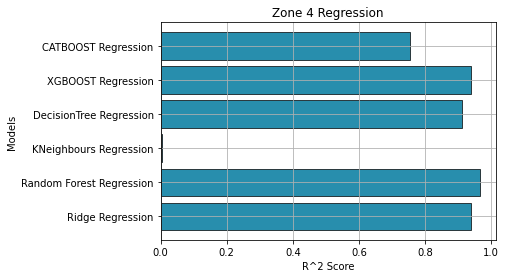

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_valeues=['Ridge Regression', 'Random Forest Regression',
           'KNeighbours Regression', 'DecisionTree Regression', 'XGBOOST Regression', 'CATBOOST Regression']

y_valeues=[model.score(X_test, y_test), rf.score(X_test, y_test), neigh.score(X_test, y_test), dt.score(X_test, y_test),
           xgb.score(X_test, y_test), catb.score(X_test, y_test)]

width=1

# plot
plt.barh(x_valeues, y_valeues, color='#288ead', edgecolor="black", linewidth=0.7)

plt.xlabel('R^2 Score')
plt.ylabel('Models')
plt.title('Zone 4 Regression')
plt.grid(True)

plt.show()